# A01 Test-Spoof Subset Inspection

This notebook inspects the prepared ASVspoof5 manifest for system `A01` and focuses on the `test` split spoof examples only.

The goal here is not to run TCAV yet. It is to measure speaker coverage and utterance availability so we can choose a speaker-balanced subset with a fixed random seed later.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid')

In [2]:
# ===== Config =====
PROJECT_ROOT = Path('/home/SpeakerRec/BioVoice')
PLAN_BASE = (
    PROJECT_ROOT
    / 'data'
    / 'datasets'
    / 'ASVspoof5_tars'
    / 'ASVspoof5_protocols'
    / 'train_dev_16_systems_outputs'
)

SOURCE_PARTITION = 'train'
SYSTEM_ID = 'A01'
TARGET_SPLIT = 'test'
MIN_UTT_THRESHOLDS = [1, 2, 3, 4, 5, 8, 10]

MANIFEST_PATH = PLAN_BASE / SOURCE_PARTITION / 'selected_utterances_plan.csv'
print('MANIFEST_PATH =', MANIFEST_PATH)
print('exists =', MANIFEST_PATH.exists())

MANIFEST_PATH = /home/SpeakerRec/BioVoice/data/datasets/ASVspoof5_tars/ASVspoof5_protocols/train_dev_16_systems_outputs/train/selected_utterances_plan.csv
exists = True


In [3]:
# ===== Load manifest =====
assert MANIFEST_PATH.exists(), f'Missing manifest: {MANIFEST_PATH}'

manifest = pd.read_csv(MANIFEST_PATH)
required_cols = {
    'split',
    'speaker_id',
    'utt_id',
    'gender',
    'label',
    'system_id',
    'sample_class',
    'target_class',
}
missing = required_cols - set(manifest.columns)
if missing:
    raise ValueError(f'Manifest missing columns: {sorted(missing)}')

print('rows =', len(manifest))
display(manifest.head(10))

rows = 123318


,source_partition,split,speaker_id,utt_id,gender,label,system_id,sample_class,codec_id,target_class
0,train,test,T_0039,T_0000001411,F,spoof,A01,A01,AC2,A01
1,train,test,T_0039,T_0000003977,F,spoof,A01,A01,AC2,A01
2,train,test,T_0039,T_0000010295,F,spoof,A01,A01,AC2,A01
3,train,test,T_0039,T_0000017554,F,spoof,A01,A01,AC2,A01
4,train,test,T_0039,T_0000021681,F,spoof,A01,A01,AC2,A01
5,train,test,T_0039,T_0000032942,F,spoof,A01,A01,AC2,A01
6,train,test,T_0039,T_0000039301,F,spoof,A01,A01,AC2,A01
7,train,test,T_0039,T_0000043732,F,spoof,A01,A01,AC2,A01
8,train,test,T_0039,T_0000057819,F,spoof,A01,A01,AC2,A01
9,train,test,T_0039,T_0000068392,F,spoof,A01,A01,AC2,A01


In [4]:
# ===== Focus on A01 spoof examples in the test split =====
a01_test_spoof = manifest[
    manifest['split'].eq(TARGET_SPLIT)
    & manifest['target_class'].eq(SYSTEM_ID)
].copy().reset_index(drop=True)

assert not a01_test_spoof.empty, f'No {SYSTEM_ID} rows found in split={TARGET_SPLIT}'

summary = {
    'system_id': SYSTEM_ID,
    'split': TARGET_SPLIT,
    'rows': int(len(a01_test_spoof)),
    'unique_speakers': int(a01_test_spoof['speaker_id'].nunique()),
    'unique_utterances': int(a01_test_spoof['utt_id'].nunique()),
}
display(pd.DataFrame([summary]))
display(a01_test_spoof.head(20))

,system_id,split,rows,unique_speakers,unique_utterances
0,A01,test,4475,120,4475


,source_partition,split,speaker_id,utt_id,gender,label,system_id,sample_class,codec_id,target_class
0,train,test,T_0039,T_0000001411,F,spoof,A01,A01,AC2,A01
1,train,test,T_0039,T_0000003977,F,spoof,A01,A01,AC2,A01
2,train,test,T_0039,T_0000010295,F,spoof,A01,A01,AC2,A01
3,train,test,T_0039,T_0000017554,F,spoof,A01,A01,AC2,A01
4,train,test,T_0039,T_0000021681,F,spoof,A01,A01,AC2,A01
5,train,test,T_0039,T_0000032942,F,spoof,A01,A01,AC2,A01
6,train,test,T_0039,T_0000039301,F,spoof,A01,A01,AC2,A01
7,train,test,T_0039,T_0000043732,F,spoof,A01,A01,AC2,A01
8,train,test,T_0039,T_0000057819,F,spoof,A01,A01,AC2,A01
9,train,test,T_0039,T_0000068392,F,spoof,A01,A01,AC2,A01


In [5]:
# ===== Speaker coverage table =====
speaker_counts = (
    a01_test_spoof.groupby('speaker_id')
    .agg(
        n_utterances=('utt_id', 'size'),
        n_unique_utterances=('utt_id', 'nunique'),
        gender=('gender', 'first'),
    )
    .reset_index()
    .sort_values(['n_utterances', 'speaker_id'], ascending=[False, True])
    .reset_index(drop=True)
)

display(speaker_counts.head(30))
display(
    pd.DataFrame(
        [
            {
                'min_utterances_per_speaker': int(speaker_counts['n_utterances'].min()),
                'median_utterances_per_speaker': float(speaker_counts['n_utterances'].median()),
                'max_utterances_per_speaker': int(speaker_counts['n_utterances'].max()),
                'mean_utterances_per_speaker': float(speaker_counts['n_utterances'].mean()),
            }
        ]
    )
)

,speaker_id,n_utterances,n_unique_utterances,gender
0,T_3912,54,54,F
1,T_1779,52,52,F
2,T_0141,51,51,F
3,T_0218,51,51,F
4,T_2149,51,51,M
5,T_1122,49,49,M
6,T_2563,49,49,F
7,T_1593,48,48,F
8,T_4459,48,48,F
9,T_0291,47,47,M


,min_utterances_per_speaker,median_utterances_per_speaker,max_utterances_per_speaker,mean_utterances_per_speaker
0,16,40.0,54,37.291667


In [6]:
# ===== Feasibility by minimum utterance threshold =====
threshold_rows = []
for min_utts in MIN_UTT_THRESHOLDS:
    eligible = speaker_counts[speaker_counts['n_utterances'] >= min_utts].copy()
    threshold_rows.append(
        {
            'min_utts_per_speaker': int(min_utts),
            'eligible_speakers': int(len(eligible)),
            'available_utterances_if_balanced': int(len(eligible) * min_utts),
        }
    )

threshold_df = pd.DataFrame(threshold_rows)
display(threshold_df)

,min_utts_per_speaker,eligible_speakers,available_utterances_if_balanced
0,1,120,120
1,2,120,240
2,3,120,360
3,4,120,480
4,5,120,600
5,8,120,960
6,10,120,1200


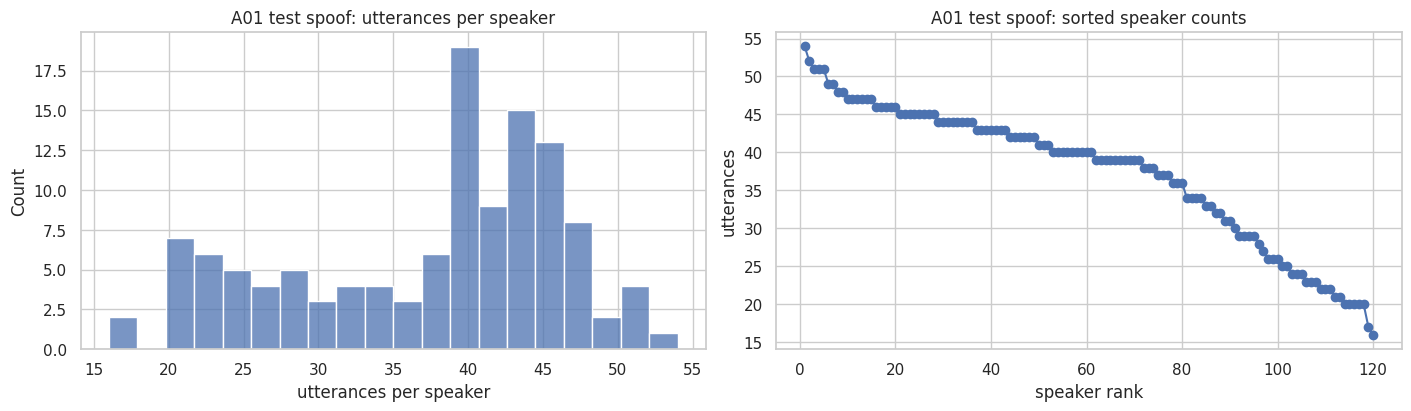

In [7]:
# ===== Distribution plots =====
fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)

sns.histplot(speaker_counts['n_utterances'], bins=min(20, max(5, speaker_counts['n_utterances'].nunique())), ax=axes[0])
axes[0].set_title(f'{SYSTEM_ID} test spoof: utterances per speaker')
axes[0].set_xlabel('utterances per speaker')

axes[1].plot(range(1, len(speaker_counts) + 1), speaker_counts['n_utterances'].to_numpy(), marker='o')
axes[1].set_title(f'{SYSTEM_ID} test spoof: sorted speaker counts')
axes[1].set_xlabel('speaker rank')
axes[1].set_ylabel('utterances')

plt.show()

In [8]:
# ===== Candidate balanced subset sizes =====
candidate_rows = []
for min_utts in MIN_UTT_THRESHOLDS:
    eligible = speaker_counts[speaker_counts['n_utterances'] >= min_utts].copy()
    n_spk = int(len(eligible))
    if n_spk == 0:
        continue
    candidate_rows.append(
        {
            'utters_per_speaker': int(min_utts),
            'max_balanced_speakers': n_spk,
            'max_total_subset_rows': int(n_spk * min_utts),
            'example_8_speakers_total_rows': int(min(8, n_spk) * min_utts),
            'example_12_speakers_total_rows': int(min(12, n_spk) * min_utts),
        }
    )

candidate_df = pd.DataFrame(candidate_rows)
display(candidate_df)

,utters_per_speaker,max_balanced_speakers,max_total_subset_rows,example_8_speakers_total_rows,example_12_speakers_total_rows
0,1,120,120,8,12
1,2,120,240,16,24
2,3,120,360,24,36
3,4,120,480,32,48
4,5,120,600,40,60
5,8,120,960,64,96
6,10,120,1200,80,120


## Next Decision

After reviewing the tables above, choose a speaker-balanced policy for `A01`, for example:

- fixed number of speakers `K`
- fixed number of spoof utterances per speaker `M`
- random sampling with a fixed seed

Once that is fixed, the next notebook or script can materialize the subset and then run TCAV for `A01`.